# Escaneo de Horizontes · Riesgo geopolítico para México (2026)
**Autor:** Max Santana · *Anticipación & Estrategia*

Notebook reproducible del proyecto: limpieza de la base de señales, codificación en drivers, clasificación en la Matriz Impacto/Incertidumbre (MIU) y diagnóstico de sesgos en la evaluación.

## 1. Carga y limpieza
La base se construyó en Google Sheets como material del Módulo 4 del curso de Gestión de Riesgo Geopolítico (Tec de Monterrey, agosto 2026). `clean.py` documenta cada corrección.

In [1]:
import sys; sys.path.insert(0, '../src')
import pandas as pd
import clean, analyze, figures
pd.set_option('display.max_colwidth', 80)
df_clean = clean.main()
pd.read_csv('../data/processed/data_quality_log.csv').groupby('campo').size()

43 señales limpias · 45 incidencias registradas


campo
arquetipo_dator                         6
cla                                     6
descripcion/como_cambia/stakeholders    1
fecha_publicacion                       5
foda                                    8
futuros_integrales                      6
id                                      1
nivel_kuosa                             6
sombrero_mad_hatter                     6
dtype: int64

In [2]:
df_clean[['pestle','horizonte','tipo_hallazgo','efecto','ambito']].apply(lambda s: s.value_counts()).fillna(0).astype(int)

,pestle,horizonte,tipo_hallazgo,efecto,ambito
Ambiental,6,0,0,0,0
Confirma escenario actual,0,0,0,18,0
Corto (1-3 años),0,16,0,0,0
Crea nuevo escenario,0,0,0,24,0
Económico,10,0,0,0,0
Evento potencial,0,0,6,0,0
Global,0,0,0,0,13
Hecho actual,0,0,10,0,0
Largo (6-10 años),0,10,0,0,0
Legal,5,0,0,0,0


## 2. Drivers, MIU e índices
- **Drivers:** codificación temática analítica (7 drivers).
- **MIU:** Impacto₁₀ = impacto × 2; Incertidumbre₁₀ = (6 − probabilidad) × 2; umbrales del curso (tendencia pesada, fuerza crítica, fuerza importante).
- **Índice de señal débil:** promedio de novedad, (6 − probabilidad) y oportunidad temporal.

In [3]:
df, summ, corr = analyze.main()
summ

                                                 n  impacto_medio  probabilidad_media  novedad_media  riesgo_ixp_medio  pct_mexico  tendencias_pesadas  senales_debiles
driver                                                                                                                                                                 
D1 Reconfiguración comercial norteamericana      8           4.00                4.50           2.00              18.0       100.0                   7                0
D3 Fragilidad de infraestructura crítica         6           3.83                4.50           2.33              17.3       100.0                   3                0
D4 Erosión institucional y certidumbre jurídica  4           3.50                4.25           2.00              15.8       100.0                   2                1
D2 Securitización de la relación México-EE. UU.  6           3.00                4.00           3.00              12.3        67.0                   1          

,n,impacto_medio,probabilidad_media,novedad_media,riesgo_ixp_medio,pct_mexico,tendencias_pesadas,senales_debiles
driver,,,,,,,,
D1 Reconfiguración comercial norteamericana,8,4.00,4.50,2.00,18.0,100.0,7,0
D3 Fragilidad de infraestructura crítica,6,3.83,4.50,2.33,17.3,100.0,3,0
D4 Erosión institucional y certidumbre jurídica,4,3.50,4.25,2.00,15.8,100.0,2,1
D2 Securitización de la relación México-EE. UU.,6,3.00,4.00,3.00,12.3,67.0,1,2
D5 Ecosistema informacional y cohesión social,5,2.80,3.80,2.80,10.8,60.0,1,1
D7 Riesgo físico-ambiental y gobernanza global,5,2.20,2.40,2.60,5.2,60.0,0,1
D6 Competencia geoeconómica y nuevas fronteras,9,1.78,2.44,3.33,4.9,22.0,1,5


In [4]:
df[df.miu != 'Monitoreo'][['id','driver_code','impacto','probabilidad','novedad','miu','titulo']].sort_values(['miu','impacto'], ascending=[True, False])

,id,driver_code,impacto,probabilidad,novedad,miu,titulo
20,S21,D7,5,2,2,Fuerza crítica,Terremotos recientes en Venezuela y Colombia reactivan el debate científico ...
1,S02,D2,3,3,3,Fuerza importante,Estados Unidos designa al Cartel de los Soles como Organización Terrorista E...
28,S29,D6,3,2,5,Fuerza importante,Investigadores chinos factorizan un entero RSA de 22 bits con una computador...
0,S01,D1,5,5,1,Tendencia pesada,México y EE. UU. concluyen la tercera ronda de revisión conjunta del T-MEC; ...
13,S14,D3,5,4,1,Tendencia pesada,México enfrenta un rezago estructural en ciberseguridad frente a incidentes ...
18,S19,D3,5,5,2,Tendencia pesada,"Más de 1,100 km² del área metropolitana de Monterrey perdieron capacidad de ..."
22,S23,D4,5,5,1,Tendencia pesada,El desempeño reciente de la Suprema Corte de Justicia es señalado como fuent...
5,S06,D6,4,4,1,Tendencia pesada,El Estrecho de Ormuz canaliza cerca de 25% del comercio mundial de petróleo ...
7,S08,D1,4,4,2,Tendencia pesada,EE. UU. busca cerrar vacíos de reglas de origen del T-MEC para limitar el ap...
8,S09,D1,4,4,2,Tendencia pesada,México enfrenta un segundo y más profundo choque económico por la competenci...


## 3. Diagnóstico del sesgo de evaluación
Si los criterios fueran independientes, la novedad no debería predecir el impacto. La correlación negativa indica que las señales nuevas o distantes reciben sistemáticamente menos peso.

In [5]:
corr.sort_values('rho')

,criterio_a,criterio_b,rho,p
8,oportunidad_temporal,probabilidad,-0.73,0.0000
3,impacto,oportunidad_temporal,-0.66,0.0000
9,oportunidad_temporal,plausibilidad,-0.63,0.0000
2,impacto,novedad,-0.56,0.0001
6,novedad,plausibilidad,-0.49,0.0008
5,novedad,probabilidad,-0.46,0.0017
1,impacto,plausibilidad,0.53,0.0002
0,impacto,probabilidad,0.71,0.0000
7,novedad,oportunidad_temporal,0.79,0.0000
4,plausibilidad,probabilidad,0.79,0.0000


In [6]:
df.groupby('senal_debil')[['impacto','probabilidad','novedad']].mean().round(2).rename(index={True:'Señales débiles (novedad 4-5)', False:'Resto'})

,impacto,probabilidad,novedad
senal_debil,,,
Resto,3.3,3.91,2.06
Señales débiles (novedad 4-5),1.9,2.80,4.50


In [7]:
df[df.senal_debil][['id','driver_code','impacto','probabilidad','novedad','indice_senal_debil','titulo']].sort_values('indice_senal_debil', ascending=False)

,id,driver_code,impacto,probabilidad,novedad,indice_senal_debil,titulo
26,S27,D6,1,2,5,4.67,La NASA acelera un reactor nuclear lunar para 2030 ante el riesgo de que Chi...
21,S22,D6,1,2,5,4.67,El deshielo acelerado del Ártico abre nuevas rutas comerciales y aviva la co...
29,S30,D7,1,2,4,4.00,Un estudio académico propone entender las operaciones de paz de la ONU en Ha...
12,S13,D6,1,2,4,4.00,El estatus de puerto seguro de Dubái es puesto a prueba tras los ataques de ...
27,S28,D6,1,2,4,4.00,El Proyecto Colmena de la UNAM buscó posar cinco microrobots en la Luna dent...
28,S29,D6,3,2,5,4.00,Investigadores chinos factorizan un entero RSA de 22 bits con una computador...
37,S39,D2,3,4,5,3.67,El Congreso de EE. UU. condiciona por ley la asistencia en seguridad y comba...
3,S04,D4,2,3,4,3.33,"La Secretaría de Marina asume la administración de aeropuertos civiles, mien..."
40,S42,D5,2,4,4,3.00,"Protestas ""Generación Z"", organizadas en Discord tras el asesinato del alcal..."
38,S40,D2,4,5,5,2.33,"EE. UU. acusa y pide la extradición del gobernador de Sinaloa, Rubén Rocha M..."


## 4. Visualizaciones

Figuras guardadas en /home/claude/hs/figures


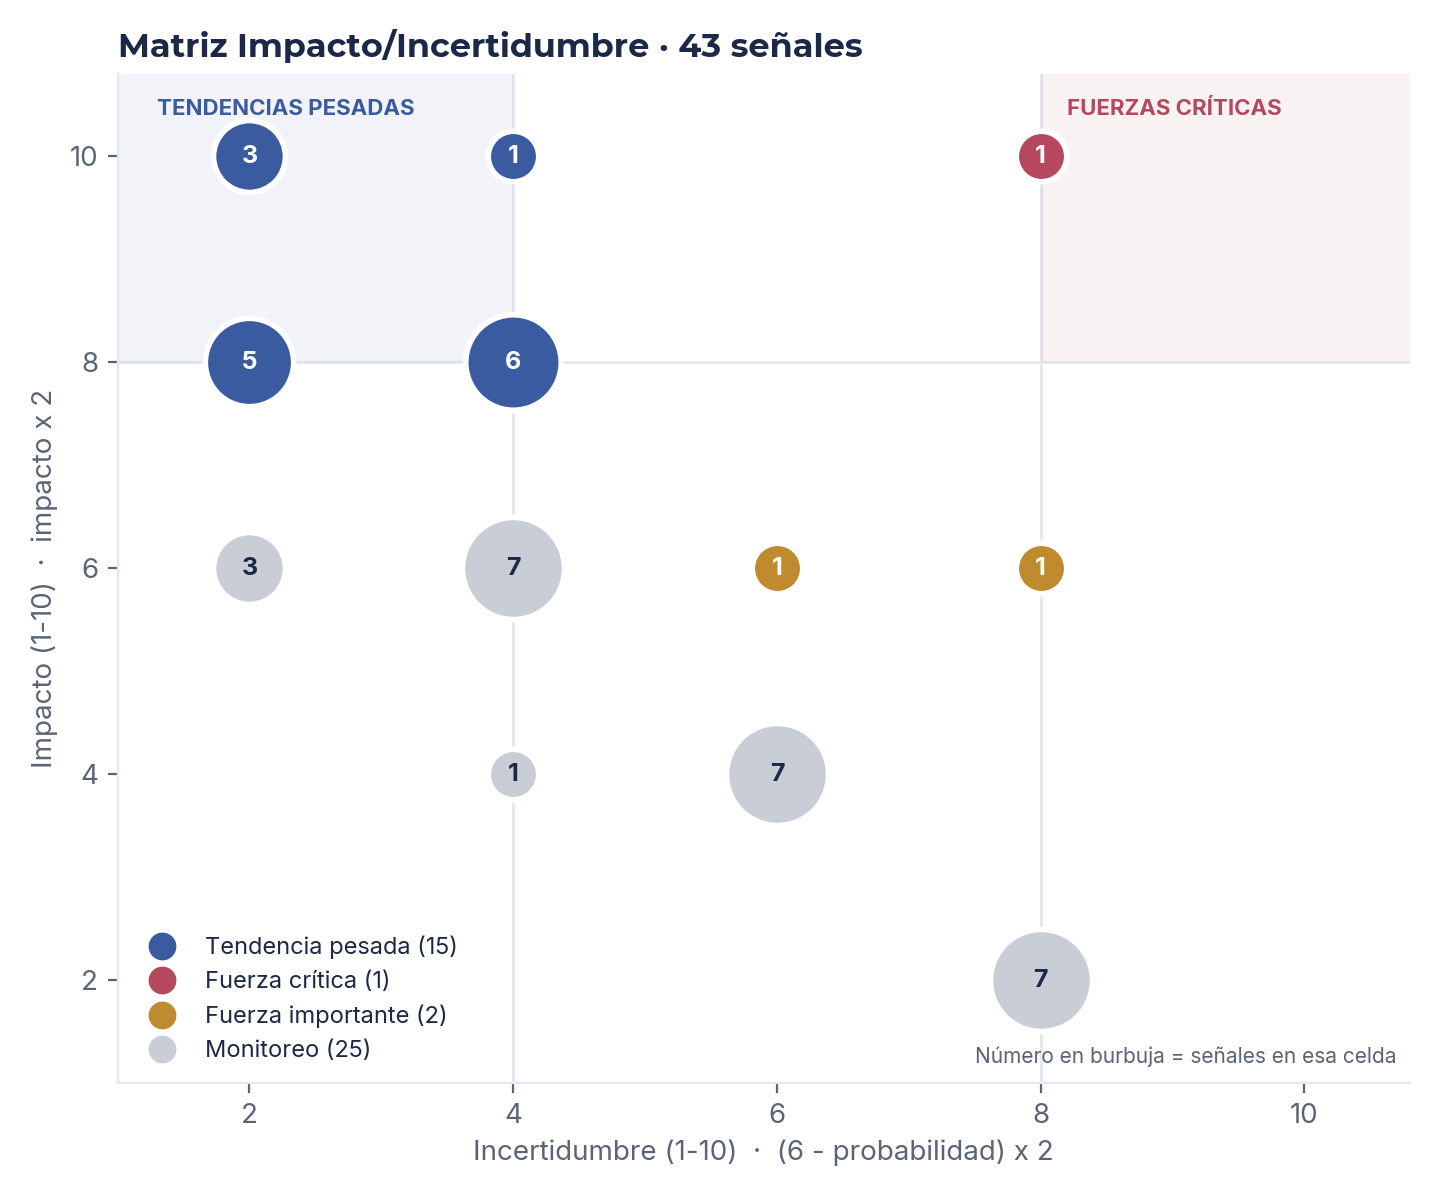

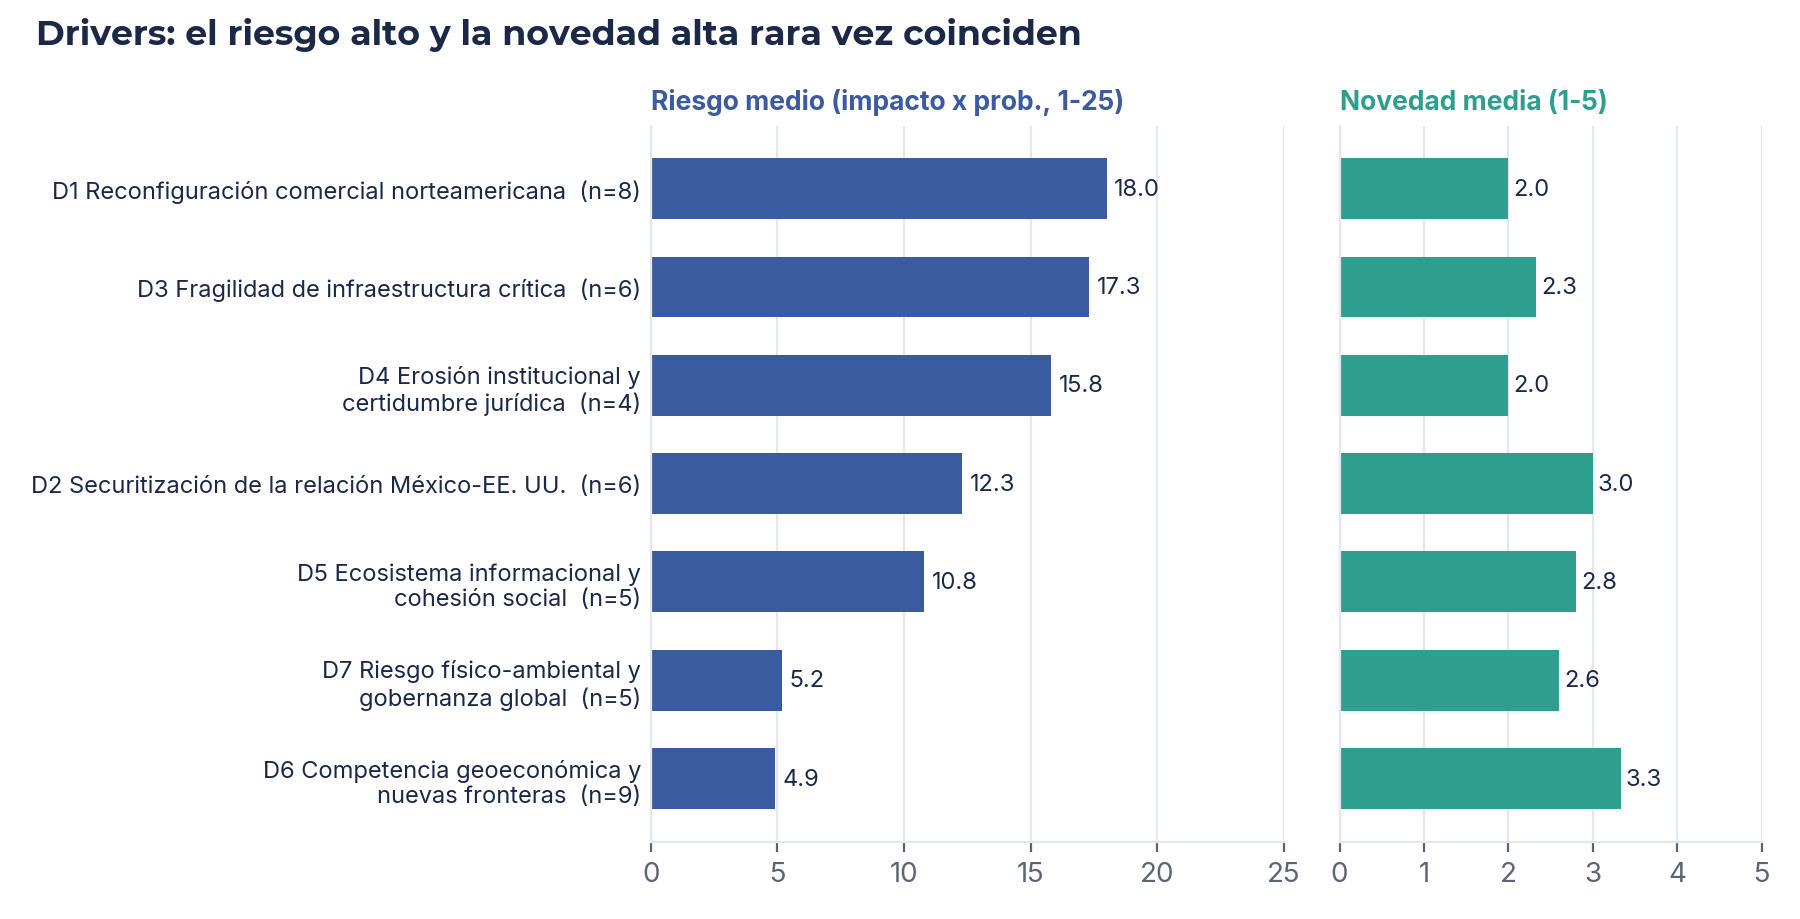

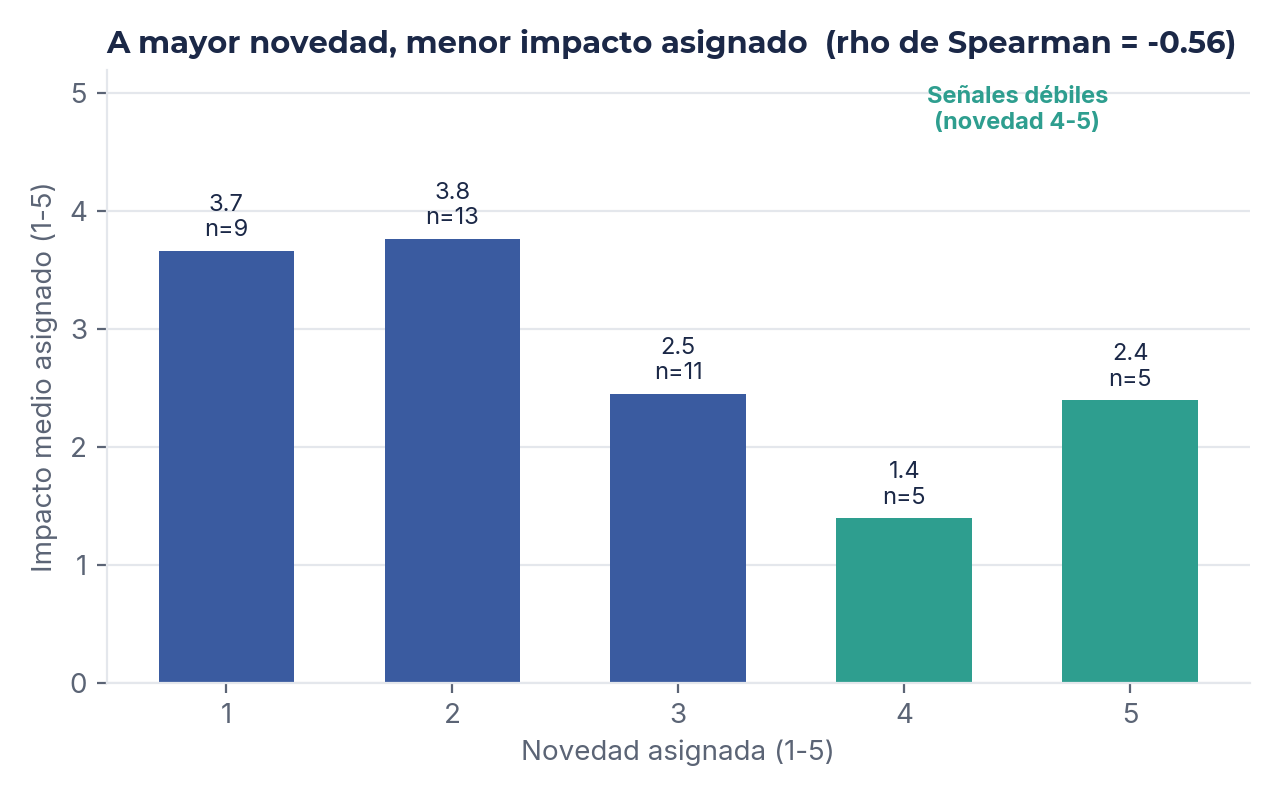

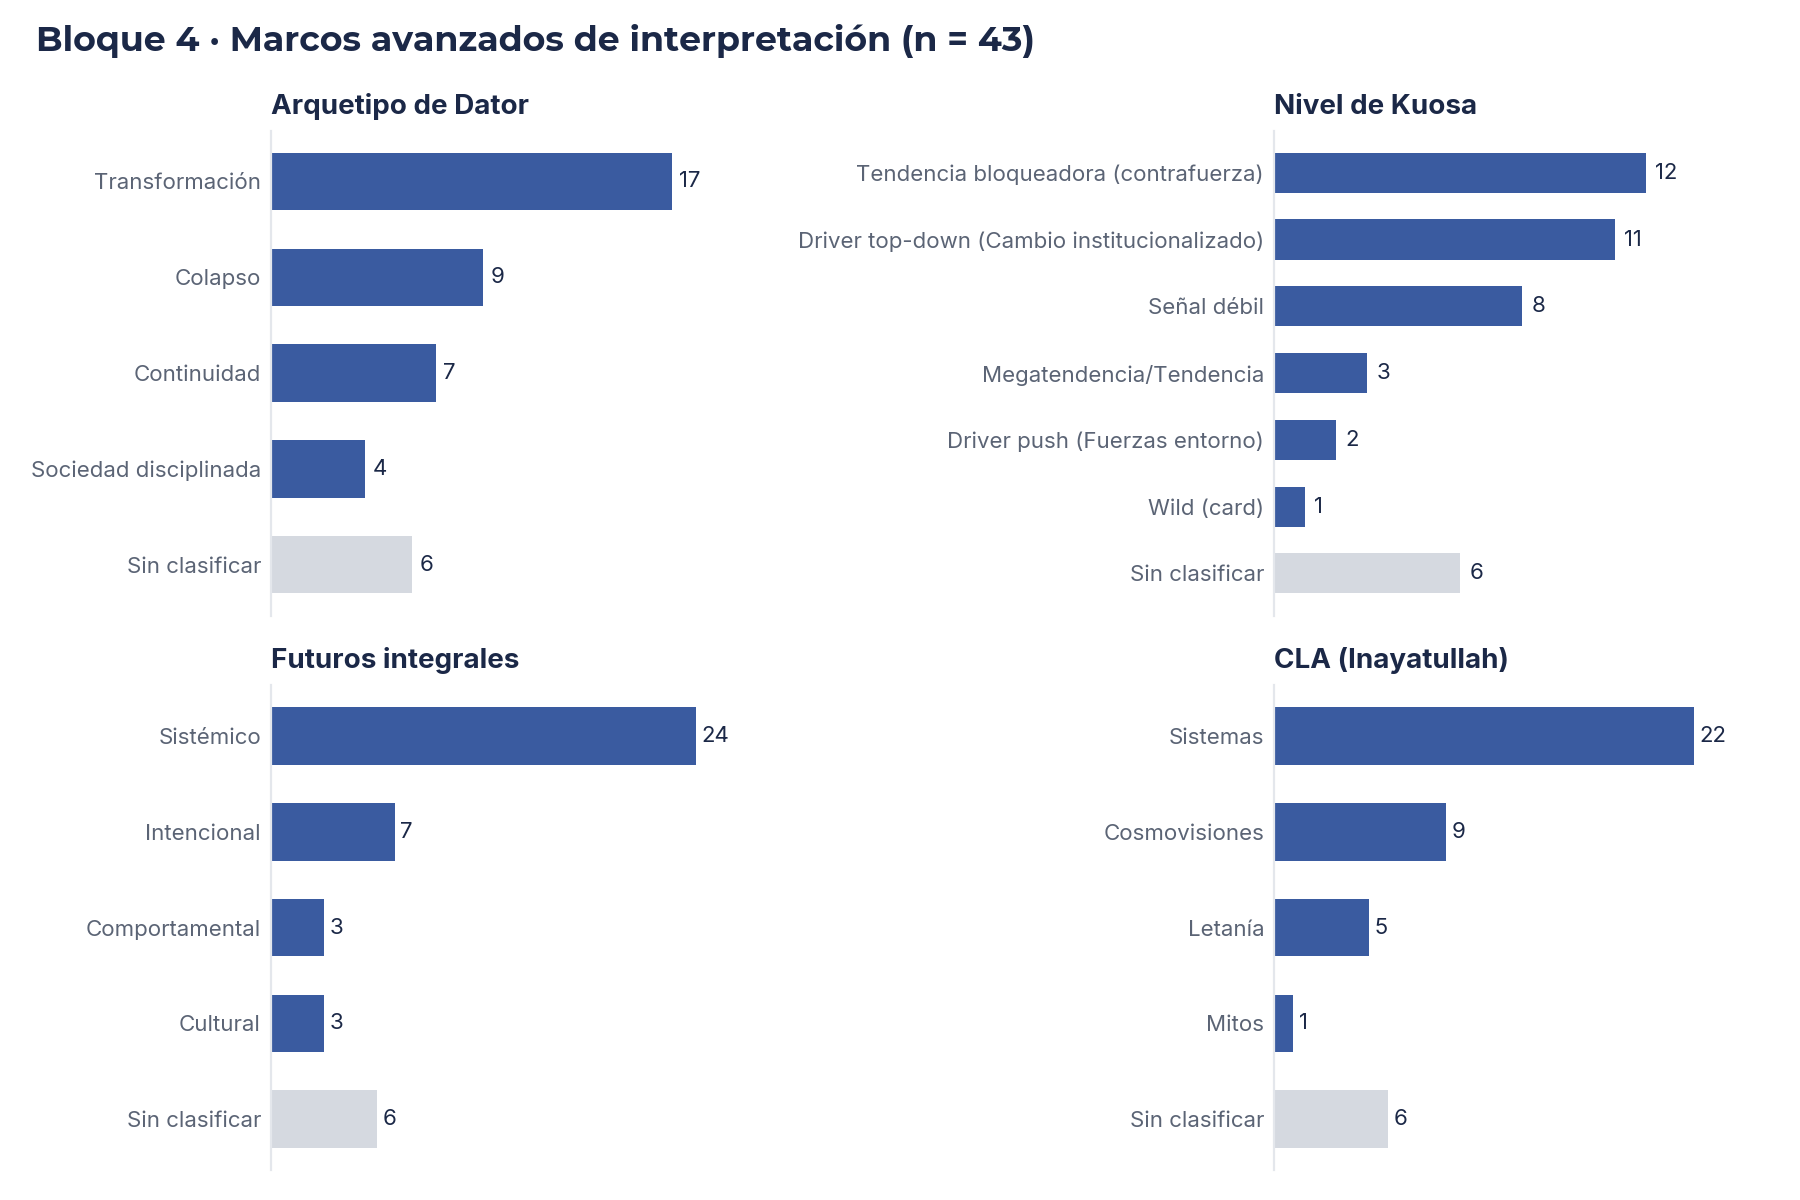

In [8]:
figures.main()
from IPython.display import Image, display
for f in ['fig1_miu','fig2_drivers','fig3_sesgo_novedad','fig4_marcos']:
    display(Image(f'../figures/{f}.png', width=720))

## 5. Lectura
1. **Concentración doméstica.** 12 de las 15 tendencias pesadas pertenecen a tres drivers internos (comercio norteamericano, infraestructura crítica, certidumbre jurídica).
2. **Sesgo contra la novedad.** ρ(novedad, impacto) = −0.56; las 10 señales débiles promedian impacto 1.9 frente a 3.3 del resto. Un escaneo priorizado solo por impacto × probabilidad se convierte en un registro de riesgos conocidos.
3. **Driver bisagra.** La securitización de la relación México-EE. UU. (D2) concentra 2 de las 3 señales que combinan novedad y probabilidad altas (≥ 4): S39 y S40 (la tercera es S42). La agenda de seguridad empieza a condicionar la política hídrica y la gobernanza subnacional.
4. **Profundidad interpretativa.** 22 de 37 señales clasificadas en CLA se quedan en el nivel *Sistemas*; solo una llega a *Mitos*. Hay espacio para leer las señales en capas más profundas.